# Train and validate the predict kidney failure model

In [1]:
# Load the training dataset

import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
data_path = os.getenv('TRAINING_DATA')
train = pd.read_csv(data_path)
train = train.dropna()
train = train.drop(columns = 'Studio')
train.shape

(3599, 19)

### Further preprocess the data

In [3]:
train.columns

Index(['Sesso', 'Diabete', 'ESRD', 'Eta1', 'Prot1', 'Creat1', 'Epi1',
       'Colesterolo1', 'Hb1', 'Ca1', 'P1', 'BMI1', 'ckd_cause_hypertens',
       'ckd_cause_diabet', 'ckd_cause_glom_dis', 'ckd_cause_tubul_inter',
       'ckd_cause_pkd', 'esrd_upper', 'esrd_lower'],
      dtype='object')

<Axes: xlabel='esrd_lower', ylabel='Count'>

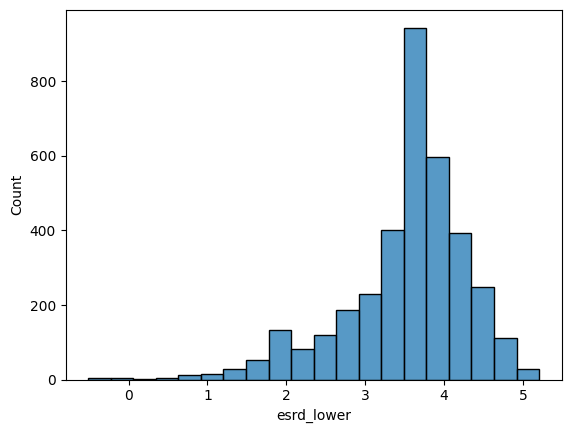

In [4]:
import seaborn as sns
import math

sns.histplot(np.log(train['esrd_lower']), bins=20)

<Axes: xlabel='esrd_lower', ylabel='Count'>

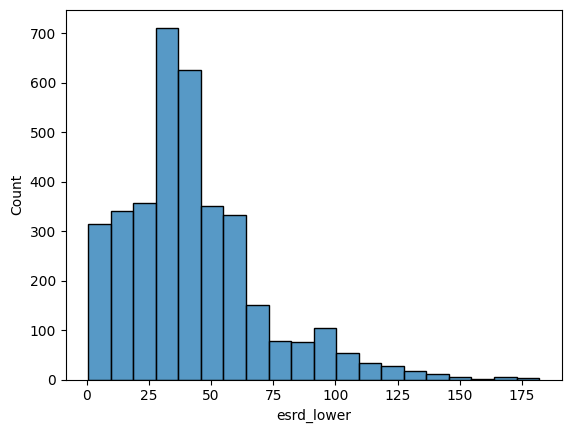

In [5]:
sns.histplot(train['esrd_lower'], bins=20)

In [6]:
print(train.columns)

Index(['Sesso', 'Diabete', 'ESRD', 'Eta1', 'Prot1', 'Creat1', 'Epi1',
       'Colesterolo1', 'Hb1', 'Ca1', 'P1', 'BMI1', 'ckd_cause_hypertens',
       'ckd_cause_diabet', 'ckd_cause_glom_dis', 'ckd_cause_tubul_inter',
       'ckd_cause_pkd', 'esrd_upper', 'esrd_lower'],
      dtype='object')


In [7]:
labelcols = {
    'lower': 'esrd_lower',
    'upper': 'esrd_upper'
}

In [8]:
# Import the results of the feature selection
import json

with open('raw_results/feature_selection_results.json') as f:
    var_dict = json.load(f)

In [9]:
df_feat_import = pd.DataFrame({'feat': var_dict['feat'], 'c_index': var_dict['c_index']})
df_feat_import['c_index'] = round(df_feat_import['c_index'], 2)
selected_feat = list(df_feat_import['feat'])[:np.argmax(df_feat_import['c_index']) + 3]
selected_feat

['Epi1', 'Prot1', 'BMI1', 'Eta1', 'P1', 'Ca1', 'Hb1', 'Colesterolo1']

In [10]:
train = train[list(selected_feat + [labelcols['lower'], labelcols['upper']])]

In [11]:
print(list(train.columns))

['Epi1', 'Prot1', 'BMI1', 'Eta1', 'P1', 'Ca1', 'Hb1', 'Colesterolo1', 'esrd_lower', 'esrd_upper']


In [12]:
train.rename(columns={'Epi1': 'EGFR', 
                      'Prot1': 'URIN_PROT', 
                      'BMI1': 'BMI', 
                      'Eta1': 'AGE', 
                      'P1': 'PHOSPHORUS', 
                      'Ca1': 'CALCIUM', 
                      'Hb1': 'HB', 
                      'Colesterolo1': 'CHOLESTEROL'}, inplace=True)

In [13]:
print(list(train.columns))

['EGFR', 'URIN_PROT', 'BMI', 'AGE', 'PHOSPHORUS', 'CALCIUM', 'HB', 'CHOLESTEROL', 'esrd_lower', 'esrd_upper']


In [14]:
best_params = var_dict['best_hyperparams'][np.argmax(df_feat_import['c_index'])+2]
best_params

['extreme', 0.1, [8, 10], 50, [1.0, 3.0]]

In [15]:
best_params = {'objective': 'survival:aft',
               'eval_metric': 'aft-nloglik',
               'aft_loss_distribution': 'extreme',
               'aft_loss_distribution_scale': 0.1,
               'tree_method': 'hist',
               'learning_rate': 0.01,
               'max_depth': [8,10],
               'booster': 'gbtree',
               'subsample': 1.0,
               'min_child_weight': 1.0,
               'colsample_bynode': 1.0,
               'n_models': 50,
               'subset_fraction': 1.0}

In [16]:
import bagging

model = bagging.BaggingXGBRegressor(params = best_params, 
                                    labelcols=labelcols, 
                                    verbose = True)

model.train(train, early_stopping_rounds=150, num_boost_round=1500, verbose_eval=500)

N duplicated samples: 1348 from 3599
[0]	train-aft-nloglik:27.61305	eval-aft-nloglik:27.61340


/Users/tamasszili-torok/Research/machine_learning/ESKD-predict/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[500]	train-aft-nloglik:3.93431	eval-aft-nloglik:7.59560
[1000]	train-aft-nloglik:0.36671	eval-aft-nloglik:4.55507
[1499]	train-aft-nloglik:0.35524	eval-aft-nloglik:4.26697
Model number : 1 out of 50

N duplicated samples: 1326 from 3599
[0]	train-aft-nloglik:27.62364	eval-aft-nloglik:27.60449
[500]	train-aft-nloglik:3.43749	eval-aft-nloglik:7.98246
[1000]	train-aft-nloglik:0.37351	eval-aft-nloglik:3.97218
[1499]	train-aft-nloglik:0.37125	eval-aft-nloglik:3.63932
Model number : 2 out of 50

N duplicated samples: 1310 from 3599
[0]	train-aft-nloglik:27.62781	eval-aft-nloglik:27.59278
[500]	train-aft-nloglik:4.05348	eval-aft-nloglik:7.30993
[1000]	train-aft-nloglik:0.37191	eval-aft-nloglik:4.37402
[1499]	train-aft-nloglik:0.36502	eval-aft-nloglik:3.90243
Model number : 3 out of 50

N duplicated samples: 1335 from 3599
[0]	train-aft-nloglik:27.61822	eval-aft-nloglik:27.60227
[500]	train-aft-nloglik:3.31656	eval-aft-nloglik:7.65113
[1000]	train-aft-nloglik:0.37055	eval-aft-nloglik:4.11512


In [17]:
# Save the models and some raw data
model_path = os.getenv('MODEL')
model.save(model_path)